# 01 – Data Understanding
Ziel: Rohdaten kennenlernen, Qualität prüfen, erste Plots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data.load_data import load_production, get_production_path

DATE_COL = 'timestamp'
PROD_COL = 'power'
WIND_COL = 'wind_speed'

print(f'Produktionsdatei: {get_production_path()}')
df = load_production()

print(df.shape)
df.head()


Produktionsdatei: /Users/noahweis/wind_bidding_project/data/raw/Daten zur Windkennlinie_2025-09-17
[INFO] Obbach: auto-filtering to 2023 (use years param to override)

Obbach: 60 Datei(en)
  Lade: 202301_WEA 1_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202301_WEA 2_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202301_WEA 3_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202301_WEA 4_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202301_WEA 5_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202302_WEA 1_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202302_WEA 2_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202302_WEA 3_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202302_WEA 4_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202302_WEA 5_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202303_WEA 1_MeterReading_OperationalData_WindTurbine.xlsx
  Lade: 202303_WEA 2_MeterReading_OperationalData_WindTurbine.xlsx
  Lade:

,timestamp,power,wind_speed,site
0,2023-01-01 00:00:00,2472.435,9.5175,Obbach
1,2023-01-01 00:10:00,2519.575,9.8775,Obbach
2,2023-01-01 00:20:00,2517.955,9.8175,Obbach
3,2023-01-01 00:30:00,2488.8775,9.35,Obbach
4,2023-01-01 00:40:00,2506.175,9.675,Obbach


## Spalten und Datentypen
Welche Spalten gibt es? Stimmen die Typen?

In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4553892 entries, 0 to 4553891
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   timestamp   datetime64[us]
 1   power       object        
 2   wind_speed  object        
 3   site        str           
dtypes: datetime64[us](1), object(2), str(1)
memory usage: 139.0+ MB


,timestamp
count,4553892
mean,2020-05-09 21:37:20.854835
min,2014-01-02 00:00:00
25%,2017-12-01 10:10:00
50%,2020-05-09 00:35:00
75%,2023-01-21 23:00:00
max,2025-08-31 23:50:00


## Fehlende Werte

In [3]:
#optional, da fehlerhafte Summary Zeile entfernt
df.isnull().sum().sort_values(ascending=False)

timestamp     0
power         0
wind_speed    0
site          0
dtype: int64

## Zeitreihe: Leistung über Zeit
TODO: Spaltennamen anpassen

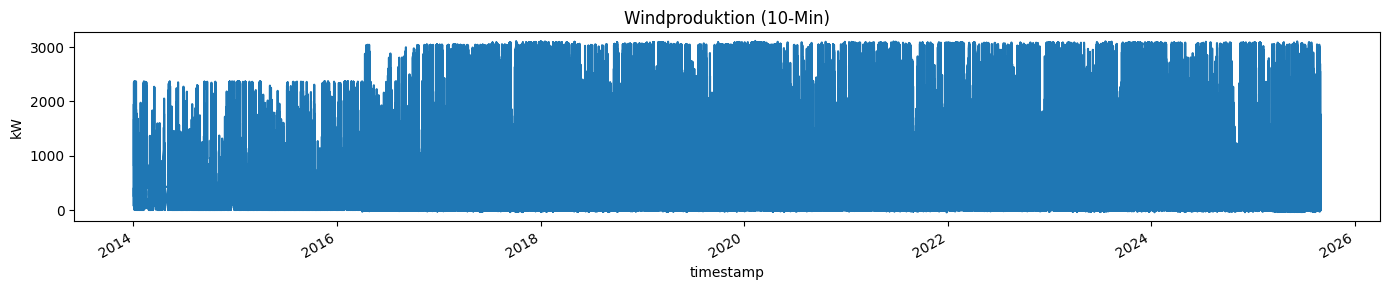

In [4]:
df.set_index(DATE_COL)[PROD_COL].plot(figsize=(14,3), title='Windproduktion (10-Min)')
plt.ylabel('kW')
plt.tight_layout()


## Verteilung Leistung

Text(0.5, 0, 'kW')

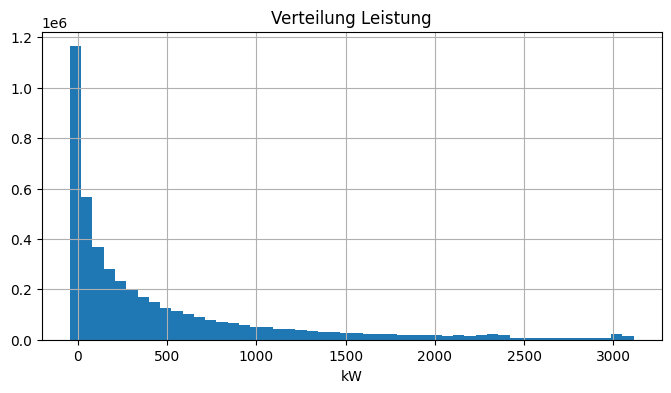

In [5]:
df[PROD_COL].hist(bins=50, figsize=(8,4))
plt.title('Verteilung Leistung')
plt.xlabel('kW')

## Wind Speed vs. Power (Power Curve)
Das ist die physikalische Beziehung – sollte eine S-Kurve sein.

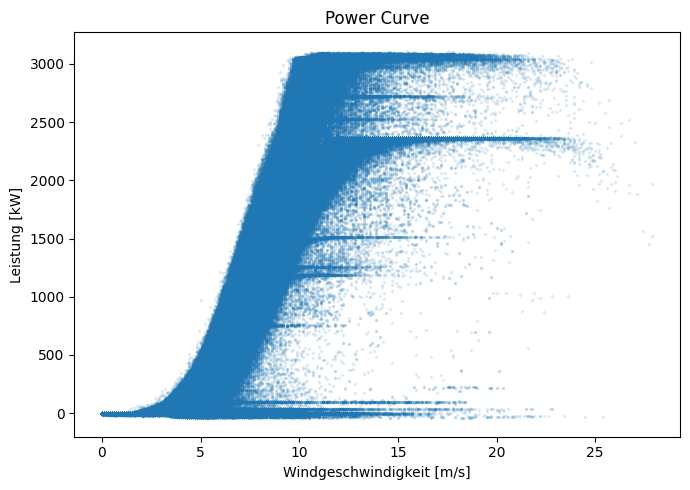

In [6]:
plt.figure(figsize=(7,5))
plt.scatter(df[WIND_COL], df[PROD_COL], alpha=0.1, s=2)
plt.xlabel('Windgeschwindigkeit [m/s]')
plt.ylabel('Leistung [kW]')
plt.title('Power Curve')
plt.tight_layout()

## Saisonalität: Produktion nach Stunde
Gibt es Tagesverläufe?

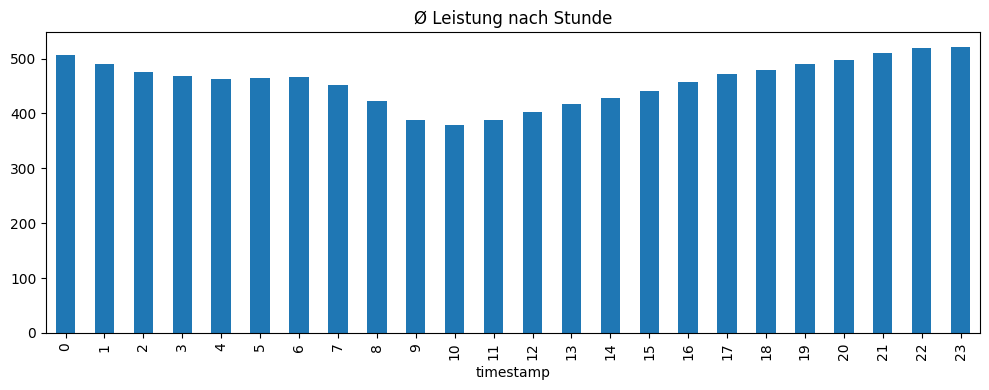

In [7]:
df['hour'] = df[DATE_COL].dt.hour
df.groupby(df[DATE_COL].dt.hour)[PROD_COL].mean().plot(kind='bar', figsize=(10,4), title='Ø Leistung nach Stunde')
plt.tight_layout()


## Wetterdaten: ECMWF IFS HRES Forecasts (Open-Meteo)

Für die operative Windleistungsprognose werden **archivierte ECMWF IFS HRES Forecasts**
über Open-Meteo (historical-forecast-api.open-meteo.com) geladen.

- Verfügbar ab 2017-01-01, stündlich, global, kostenlos, kein API-Key
- **Kein Oracle-Problem:** echte Forecasts wie zum Gebotszeitpunkt (D-1 12:00) verfügbar
- Alternativer Benchmark: ERA5-Reanalyse (perfektes Wetterwissen, nur für obere Grenze)

### Variablen
ECMWF IFS HRES liefert dieselben Variablen wie ERA5 (Pinson-Set):
Wind 100/10 m, Temperatur 2 m, Oberflächendruck, Bedeckungsgrad.

| Variable | NWP-Name | Einheit |
|---|---|---|
| Wind 100 m | wind_speed_100m | m/s |
| Wind 10 m | wind_speed_10m | m/s |
| Windrichtung | wind_direction_100m/10m | deg |
| Temperatur 2 m | temperature_2m | °C (→ K konvertieren) |
| Oberflächendruck | surface_pressure | hPa (→ Pa konvertieren) |
| Bedeckungsgrad | cloud_cover | % (→ 0–1 konvertieren) |

**Download:** `download_nwp_forecast()` in preprocessing.py; Daten nach `data/raw/nwp/`.

In [8]:
from pathlib import Path

# ── Pfade ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
WEATHER_DIR  = PROJECT_ROOT / "data" / "raw" / "weather"
WEATHER_DIR.mkdir(parents=True, exist_ok=True)

# CDS-Key (außerhalb des Projekts in ~/.cdsapirc, nicht eingecheckt)
CDS_KEY_FILE = Path.home() / ".cdsapirc"

# ── Anlagenstandorte (lat, lon) ────────────────────────────────────────────
SITES = {
    "Schonungen":  (50.05028, 10.35056),   # WP Forst-Waldsachsen 50°3'1"N 10°21'2"E
    "Schwanfeld":  (49.93361, 10.12667),   # WP Schwanfeld-Eßleben 49°56'1"N 10°7'36"E
    "Trabelsdorf": (49.90889, 10.73500),   # WKA Trabelsdorf 49°54'32"N 10°44'6"E
    "Obbach":      (50.08361, 10.07667),   # 50°5'1"N 10°4'36"E
}

# Begrenzungsrahmen für ERA5  [Nord, West, Süd, Ost] mit ±0.2° Puffer
AREA = [50.3, 9.9, 49.7, 11.0]

# ── Zeitraum ───────────────────────────────────────────────────────────────
DATE_START = "2017-03-23"   # Beginn Produktionsdaten
DATE_END   = "2025-08-31"   # Ende Produktionsdaten

print(f"Wetterordner : {WEATHER_DIR}")
print(f"Standorte    : {list(SITES)}")
print(f"ERA5-Fenster : {AREA}  [N,W,S,O]")
print(f"ERA5-Zeitraum: {DATE_START} bis {DATE_END}")
print(f"CDS-Key      : {CDS_KEY_FILE}  (existiert: {CDS_KEY_FILE.exists()})")

Wetterordner : /Users/noahweis/wind_bidding_project/data/raw/weather
Standorte    : ['Schonungen', 'Schwanfeld', 'Trabelsdorf', 'Obbach']
ERA5-Fenster : [50.3, 9.9, 49.7, 11.0]  [N,W,S,O]
ERA5-Zeitraum: 2017-03-23 bis 2025-08-31
CDS-Key      : /Users/noahweis/.cdsapirc  (existiert: False)


In [9]:
# ── NWP Download (Open-Meteo ECMWF IFS HRES) ──────────────────────────────
# Kostenlos, kein API-Key, stündlich, ab 2017-01-01

import sys
sys.path.insert(0, str(Path.cwd().parent))
from src.data.preprocessing import download_nwp_forecast

SITES = {
    "Schonungen":  (50.05028, 10.35056),
    "Schwanfeld":  (49.93361, 10.12667),
    "Trabelsdorf": (49.90889, 10.73500),
    "Obbach":      (50.08361, 10.07667),
}

NWP_DIR = PROJECT_ROOT / "data" / "raw" / "nwp"
paths = download_nwp_forecast(sites=SITES, start_date="2017-01-01", end_date="2025-08-31")
print("\nFertig. NWP-Dateien:", len(sorted(NWP_DIR.glob('nwp_*.csv'))))

  Schonungen: bereits vorhanden (nwp_schonungen.csv), skip.
  Schwanfeld: bereits vorhanden (nwp_schwanfeld.csv), skip.
  Trabelsdorf: bereits vorhanden (nwp_trabelsdorf.csv), skip.
  Obbach: bereits vorhanden (nwp_obbach.csv), skip.

Fertig. NWP-Dateien: 4


In [10]:
# ── NWP laden und Windgeschw. 100 m je Standort anzeigen ──────────────────
import pandas as pd

nwp_files = sorted(NWP_DIR.glob("nwp_*.csv"))
if not nwp_files:
    print("Keine NWP-Dateien – erst Download-Zelle ausführen.")
else:
    nwp_sites = {}
    for f in nwp_files:
        df = pd.read_csv(f)
        site = f.stem.replace("nwp_", "").title()  # kapitalisieren
        nwp_sites[site] = df.set_index("timestamp")["nwp_ws100"].rename(site)

    nwp_wind = pd.concat(nwp_sites.values(), axis=1)
    nwp_wind.index = pd.to_datetime(nwp_wind.index)

    print(f"NWP: {len(nwp_wind):,} Stunden, {nwp_wind.index.min()} bis {nwp_wind.index.max()}")
    print("\nMittlere Windgeschw. 100 m je Standort (ECMWF IFS HRES):")
    display(nwp_wind.mean().round(2).to_frame("mean_nwp_ws100 [m/s]"))

NWP: 75,960 Stunden, 2017-01-01 00:00:00 bis 2025-08-31 23:00:00

Mittlere Windgeschw. 100 m je Standort (ECMWF IFS HRES):


,mean_nwp_ws100 [m/s]
Obbach,5.19
Schonungen,4.98
Schwanfeld,4.82
Trabelsdorf,4.87


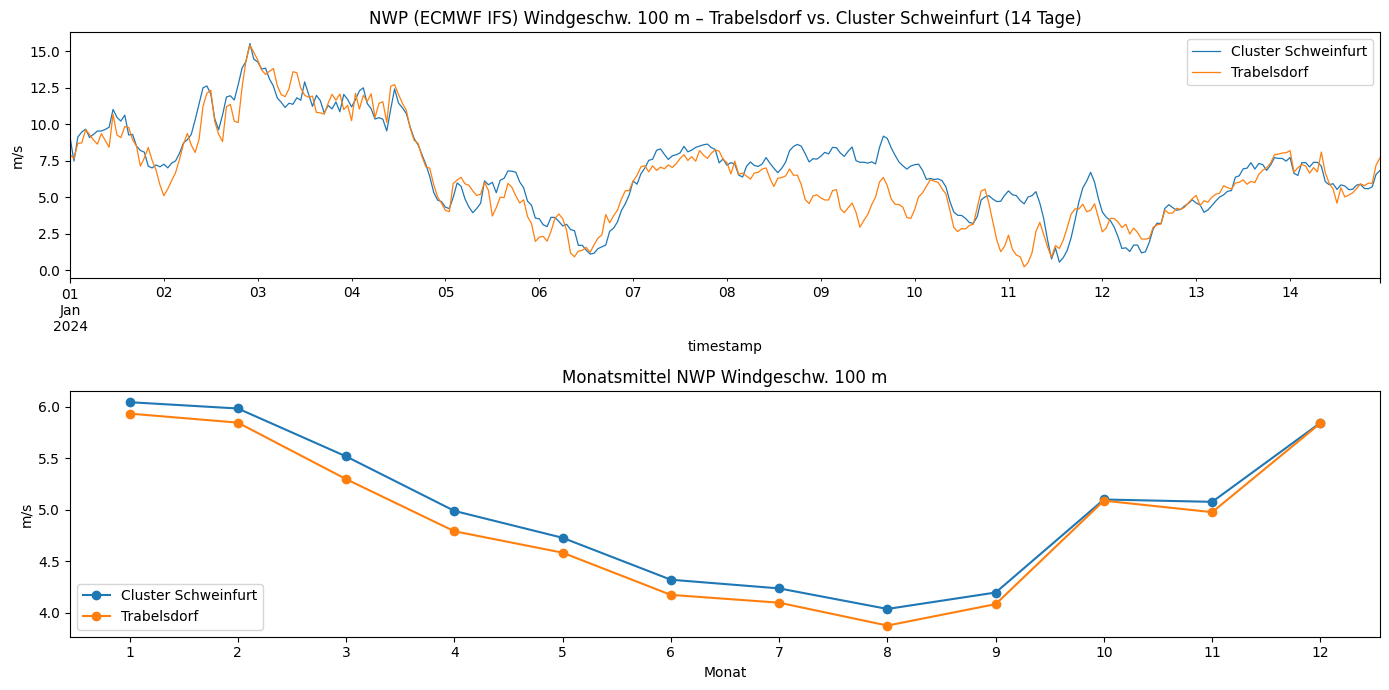

Korrelation Trabelsdorf vs. Cluster: 0.904


,mean_nwp_ws100 [m/s]
Cluster Schweinfurt,5.00
Trabelsdorf,4.87


In [11]:
# ── NWP 100 m Wind: Trabelsdorf vs. Schweinfurter Cluster ───────────────────
import matplotlib.pyplot as plt

try:
    cluster = [s for s in ["Schonungen", "Schwanfeld", "Obbach"] if s in nwp_wind.columns]
    comp = pd.concat([
        nwp_wind[cluster].mean(axis=1).rename("Cluster Schweinfurt"),
        nwp_wind["Trabelsdorf"].rename("Trabelsdorf"),
    ], axis=1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))

    # 14-Tage-Ausschnitt
    win = comp.loc["2024-01-01":"2024-01-14"]
    win.plot(ax=axes[0], linewidth=0.9)
    axes[0].set_title("NWP (ECMWF IFS) Windgeschw. 100 m – Trabelsdorf vs. Cluster Schweinfurt (14 Tage)")
    axes[0].set_ylabel("m/s")

    # Monats-Saisonalität beider Gruppen
    for name in comp.columns:
        comp[name].groupby(comp.index.month).mean().plot(ax=axes[1], marker="o", label=name)
    axes[1].set_title("Monatsmittel NWP Windgeschw. 100 m")
    axes[1].legend(); axes[1].set_xlabel("Monat"); axes[1].set_ylabel("m/s")
    axes[1].set_xticks(range(1, 13))

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "results" / "figures" / "weather_nwp_sites.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Korrelation Trabelsdorf vs. Cluster: "
          f"{comp['Trabelsdorf'].corr(comp['Cluster Schweinfurt']):.3f}")
    display(comp.mean().round(2).to_frame("mean_nwp_ws100 [m/s]"))
except NameError:
    print("Bitte zuerst die NWP-Lade-Zelle ausführen.")